## Focal Loss
## With gamma

In [18]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy
from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset

from models.basemodel import CNNWithSizeMLP

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
train_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain'
test_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest'
test_excel_path = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Size_features/size_data.xlsx'

size_lookup, species_mean_lookup, global_mean = lookup_size_from_excel(test_excel_path)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.


In [4]:

size_lookup, species_mean_lookup, global_mean = lookup_size_from_excel(test_excel_path)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
#train_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor
#test_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor

train_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = PollenFolderWithSizeDataset(img_dir=train_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=train_tf)
test_dataset = PollenFolderWithSizeDataset(img_dir=test_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=test_tf)




Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.


In [5]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")


Train subset size: 6337
Validation subset size: 1585


In [23]:
print("TRAIN class_to_idx:", train_dataset.class_to_idx)
print("TEST  class_to_idx:", test_dataset.class_to_idx)

TRAIN class_to_idx: {'Bellis perennis': 0, 'Brassica napus': 1, 'Capsella bursa-pastoris': 2, 'Cichorium intybus': 3, 'Crepis capillaris': 4, 'Hieracium umbellatum': 5, 'Hypochaeris radicata': 6, 'Sonchus arvensis': 7, 'Tragopogon pratensis': 8, 'Tussilago farfara': 9}
TEST  class_to_idx: {'Bellis perennis': 0, 'Brassica napus': 1, 'Capsella bursa-pastoris': 2, 'Cichorium intybus': 3, 'Crepis capillaris': 4, 'Hieracium umbellatum': 5, 'Hypochaeris radicata': 6, 'Sonchus arvensis': 7, 'Tragopogon pratensis': 8, 'Tussilago farfara': 9}


In [7]:
from os import access
from loss_fn.focal_loss import FocalLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
focal_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(focal_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [8]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    focal_model,
    train_subset,
    val_subset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="focal_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 199/199 [00:19<00:00, 10.17it/s]


Epoch 1/20 | Train Loss: 0.1639, Train Acc: 0.9017 | Val Loss: 0.4004, Val Acc: 0.7539
Val Recall per class: tensor([0.5152, 0.9724, 0.9032, 0.9946, 0.3803, 0.3987, 0.9197, 0.5149, 0.8545,
        0.9634])
Saved new best model (Val Acc = 0.7539)


100%|██████████| 199/199 [00:19<00:00, 10.27it/s]


Epoch 2/20 | Train Loss: 0.0974, Train Acc: 0.9348 | Val Loss: 0.1677, Val Acc: 0.8530
Saved new best model (Val Acc = 0.8530)


100%|██████████| 199/199 [00:18<00:00, 10.99it/s]


...

Epoch 18/20 | Train Loss: 0.0546, Train Acc: 0.9765 | Val Loss: 0.0477, Val Acc: 0.9672


100%|██████████| 199/199 [00:17<00:00, 11.12it/s]


Epoch 19/20 | Train Loss: 0.0675, Train Acc: 0.9740 | Val Loss: 0.0455, Val Acc: 0.9640


100%|██████████| 199/199 [00:18<00:00, 10.93it/s]


Epoch 20/20 | Train Loss: 0.0402, Train Acc: 0.9842 | Val Loss: 0.0155, Val Acc: 0.9886
Val Recall per class: tensor([1.0000, 0.9779, 0.9871, 1.0000, 1.0000, 0.9810, 0.9708, 0.9627, 1.0000,
        1.0000])
Saved new best model (Val Acc = 0.9886)
Reloaded best model from epoch 20 (Val Acc=0.9886)


In [23]:
ckpt = torch.load("models/saved_models/focal_model.pth", map_location=device)
focal_model.load_state_dict(ckpt["model_state_dict"])
focal_model.to(device)
BATCHSIZE = 32
from torchmetrics.classification import MulticlassConfusionMatrix

confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)
test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(focal_model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")



Test Accuracy: 0.8117
Test Recall per class:
Class 0 (Bellis perennis): 0.9155
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9550
Class 6 (Hypochaeris radicata): 0.7600
Class 7 (Sonchus arvensis): 0.8383
Class 8 (Tragopogon pratensis): 0.7651
Class 9 (Tussilago farfara): 1.0000


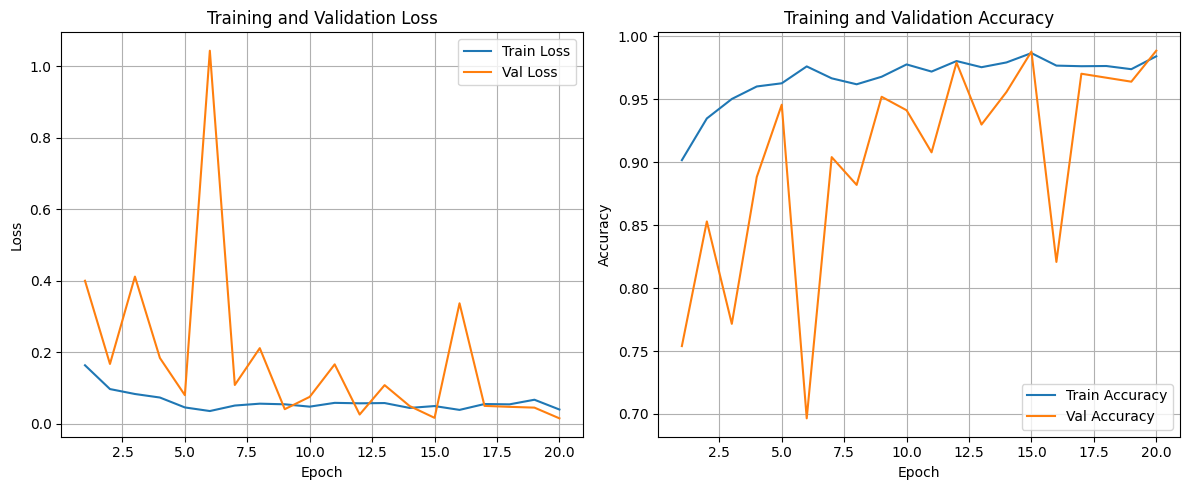

In [ ]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

## With gamma + alpha special for class 4

In [26]:
# base weights (inverse freq or effective num)
alpha = train_dataset.get_effective_num_weights(beta=0.999, device=device)

# boost Crepis capillaris (class 4)
boost = 3.0  # try 2, 3, 5
alpha[4] *= boost

alpha

tensor([0.9470, 0.9931, 0.9756, 0.9374, 2.9696, 1.0464, 1.0642, 1.1201, 0.9628,
        0.9635], device='cuda:0')

In [27]:
from os import access
from loss_fn.focal_loss import FocalLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
focal_alpha4_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = torch.optim.Adam(focal_alpha4_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [28]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    focal_alpha4_model,
    train_subset,
    val_subset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="focal_alpha4_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 199/199 [00:21<00:00,  9.11it/s]


Epoch 1/20 | Train Loss: 0.2210, Train Acc: 0.8687 | Val Loss: 0.2281, Val Acc: 0.8681
Val Recall per class: tensor([1.0000, 0.8343, 0.9871, 0.7989, 1.0000, 0.6456, 0.8978, 0.9701, 0.6061,
        0.9939])
Saved new best model (Val Acc = 0.8681)


100%|██████████| 199/199 [00:20<00:00,  9.54it/s]


Epoch 2/20 | Train Loss: 0.1127, Train Acc: 0.9309 | Val Loss: 0.0259, Val Acc: 0.9741
Saved new best model (Val Acc = 0.9741)


100%|██████████| 199/199 [00:20<00:00,  9.65it/s]


...

Epoch 8/20 | Train Loss: 0.0734, Train Acc: 0.9711 | Val Loss: 0.0565, Val Acc: 0.9590


100%|██████████| 199/199 [00:20<00:00,  9.61it/s]


Epoch 9/20 | Train Loss: 0.0377, Train Acc: 0.9822 | Val Loss: 0.1286, Val Acc: 0.9533


100%|██████████| 199/199 [00:20<00:00,  9.51it/s]


Epoch 10/20 | Train Loss: 0.0479, Train Acc: 0.9796 | Val Loss: 0.1870, Val Acc: 0.9483
Val Recall per class: tensor([1.0000, 0.9724, 0.9935, 1.0000, 0.6408, 0.9367, 1.0000, 0.9254, 0.9697,
        1.0000])
Early stopping at epoch 10. Best Val Acc = 0.9741 at epoch 2.
Reloaded best model from epoch 2 (Val Acc=0.9741)


In [29]:
ckpt = torch.load("models/saved_models/focal_alpha4_model.pth", map_location=device)
focal_model.load_state_dict(ckpt["model_state_dict"])
focal_model.to(device)


recall_per_class, accuracy, val_loss = eval_epoch(focal_alpha4_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.7399
Test Recall per class:
Class 0 (Bellis perennis): 0.0000
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 0.9846
Class 4 (Crepis capillaris): 0.0050
Class 5 (Hieracium umbellatum): 0.9250
Class 6 (Hypochaeris radicata): 0.4400
Class 7 (Sonchus arvensis): 0.9102
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


## Focal loss + augmentation (to max species)

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Only for extra samples (random, label-preserving, on PIL)
aug_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=20),
    T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02)], p=0.4),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.15),
])

# Always applied (tensor + normalize)
base_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [12]:
from Data_Utility.augmented_dataset import AugmentedPollenDataset
from Data_Utility.dataset import PollenFolderWithSizeDataset

augmented_train_dataset = AugmentedPollenDataset(
    img_dir=train_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=True,        
    transform_base=base_transform,
    transform_aug=aug_transform,
    augment=True,
    seed=42,
    shuffle_final=True,
    print_summary=True,
)

augmented_test_dataset = AugmentedPollenDataset(
    img_dir=test_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=False,        
    transform_base=base_transform,
    transform_aug=None,
    augment=False,
    seed=42,
    shuffle_final=True,
    print_summary=True,
)



Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbellatum: 800 (add 70)
  

In [13]:
print("len(samples):", len(augmented_train_dataset.samples))
print("extra_total:", augmented_train_dataset.extra_total)
print("len(mapping):", len(augmented_train_dataset.mapping))
print("expected final:", len(augmented_train_dataset.samples) + augmented_train_dataset.extra_total)

len(samples): 8078
extra_total: 622
len(mapping): 8700
expected final: 8700


In [14]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(augmented_train_dataset))
val_size = len(augmented_train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
augmented_train_subset, augmented_val_subset = random_split(augmented_train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(augmented_train_subset)}")
print(f"Validation subset size: {len(augmented_val_subset)}")

Train subset size: 6960
Validation subset size: 1740


In [16]:
train_counts = Counter([augmented_train_subset[i][2].item() for i in range(len(augmented_train_subset))])
val_counts = Counter([augmented_val_subset[i][2].item() for i in range(len(augmented_val_subset))])


In [17]:
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

print("\nValidation set class distribution:")
for k in sorted(val_counts):
    print(k, idx_to_class[int(k)], val_counts[k])

Training set class distribution:
0 Bellis perennis 701
1 Brassica napus 689
2 Capsella bursa-pastoris 685
3 Cichorium intybus 677
4 Crepis capillaris 704
5 Hieracium umbellatum 717
6 Hypochaeris radicata 704
7 Sonchus arvensis 681
8 Tragopogon pratensis 703
9 Tussilago farfara 699

Validation set class distribution:
0 Bellis perennis 169
1 Brassica napus 181
2 Capsella bursa-pastoris 185
3 Cichorium intybus 193
4 Crepis capillaris 166
5 Hieracium umbellatum 153
6 Hypochaeris radicata 166
7 Sonchus arvensis 189
8 Tragopogon pratensis 167
9 Tussilago farfara 171


In [18]:
from os import access
from loss_fn.focal_loss import FocalLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
focal_aug_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(focal_aug_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [19]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    focal_aug_model,
    augmented_train_subset,
    augmented_val_subset,
    augmented_test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="focal_aug_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 218/218 [00:20<00:00, 10.46it/s]


Epoch 1/20 | Train Loss: 0.1772, Train Acc: 0.8750 | Val Loss: 0.1542, Val Acc: 0.8851
Val Recall per class: tensor([0.9112, 0.8840, 0.9892, 0.7202, 0.9940, 0.6863, 0.8494, 0.9841, 0.8144,
        1.0000])
Saved new best model (Val Acc = 0.8851)


100%|██████████| 218/218 [00:20<00:00, 10.47it/s]


Epoch 2/20 | Train Loss: 0.0628, Train Acc: 0.9476 | Val Loss: 0.0507, Val Acc: 0.9511
Saved new best model (Val Acc = 0.9511)


100%|██████████| 218/218 [00:21<00:00, 10.28it/s]


...

Epoch 18/20 | Train Loss: 0.0105, Train Acc: 0.9897 | Val Loss: 0.0199, Val Acc: 0.9885


100%|██████████| 218/218 [00:21<00:00, 10.36it/s]


Epoch 19/20 | Train Loss: 0.0102, Train Acc: 0.9895 | Val Loss: 0.0297, Val Acc: 0.9736


100%|██████████| 218/218 [00:20<00:00, 10.39it/s]


Epoch 20/20 | Train Loss: 0.0156, Train Acc: 0.9884 | Val Loss: 0.1042, Val Acc: 0.9402
Val Recall per class: tensor([0.9704, 0.9392, 0.9243, 0.9845, 0.9880, 1.0000, 0.9819, 0.9735, 0.6587,
        0.9766])
Reloaded best model from epoch 13 (Val Acc=0.9885)


In [20]:
ckpt = torch.load("models/saved_models/focal_aug_model.pth", map_location=device)
focal_aug_model.load_state_dict(ckpt["model_state_dict"])
focal_aug_model.to(device)


recall_per_class, accuracy, val_loss = eval_epoch(focal_aug_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.8283
Test Recall per class:
Class 0 (Bellis perennis): 0.7958
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9727
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0700
Class 5 (Hieracium umbellatum): 0.8450
Class 6 (Hypochaeris radicata): 0.7500
Class 7 (Sonchus arvensis): 0.9341
Class 8 (Tragopogon pratensis): 0.9578
Class 9 (Tussilago farfara): 1.0000


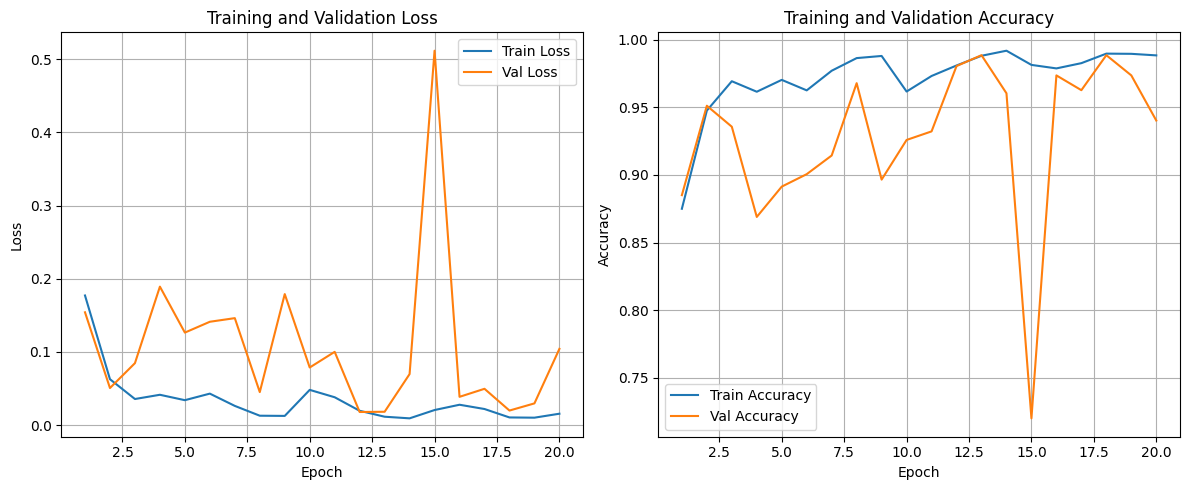

In [22]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

## Test normalization

## Focal loss + augmentation + alpha 4

In [30]:
from os import access
from loss_fn.focal_loss import FocalLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
focal_aug_alpha4_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = torch.optim.Adam(focal_aug_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  






Using device: cuda


In [31]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    focal_aug_alpha4_model,
    augmented_train_subset,
    augmented_val_subset,
    augmented_test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="focal_aug_alpha4_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 218/218 [00:24<00:00,  8.87it/s]


Epoch 1/20 | Train Loss: 2.7409, Train Acc: 0.0967 | Val Loss: 2.7354, Val Acc: 0.0862
Val Recall per class: tensor([0.0000, 0.0000, 0.1081, 0.0000, 0.0361, 0.7647, 0.0000, 0.0000, 0.0000,
        0.0409])
Saved new best model (Val Acc = 0.0862)


100%|██████████| 218/218 [00:25<00:00,  8.62it/s]


Epoch 2/20 | Train Loss: 2.7428, Train Acc: 0.0983 | Val Loss: 2.7389, Val Acc: 0.0868
Saved new best model (Val Acc = 0.0868)


100%|██████████| 218/218 [00:24<00:00,  9.06it/s]


...

Epoch 10/20 | Train Loss: 2.7370, Train Acc: 0.1003 | Val Loss: 2.7324, Val Acc: 0.0856
Val Recall per class: tensor([0.0000, 0.0000, 0.1135, 0.0000, 0.0361, 0.7451, 0.0000, 0.0000, 0.0000,
        0.0468])


100%|██████████| 218/218 [00:23<00:00,  9.16it/s]


Epoch 11/20 | Train Loss: 2.7412, Train Acc: 0.0978 | Val Loss: 2.7514, Val Acc: 0.0822


100%|██████████| 218/218 [00:23<00:00,  9.10it/s]


Epoch 12/20 | Train Loss: 2.7431, Train Acc: 0.0981 | Val Loss: 2.7186, Val Acc: 0.0862
Early stopping at epoch 12. Best Val Acc = 0.0874 at epoch 4.
Reloaded best model from epoch 4 (Val Acc=0.0874)


In [32]:
ckpt = torch.load("models/saved_models/focal_aug_alpha4_model.pth", map_location=device)
focal_aug_model.load_state_dict(ckpt["model_state_dict"])
focal_aug_model.to(device)


recall_per_class, accuracy, val_loss = eval_epoch(focal_aug_alpha4_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.0983
Test Recall per class:
Class 0 (Bellis perennis): 0.0000
Class 1 (Brassica napus): 0.0000
Class 2 (Capsella bursa-pastoris): 0.0383
Class 3 (Cichorium intybus): 0.0000
Class 4 (Crepis capillaris): 0.1550
Class 5 (Hieracium umbellatum): 0.7200
Class 6 (Hypochaeris radicata): 0.0000
Class 7 (Sonchus arvensis): 0.0030
Class 8 (Tragopogon pratensis): 0.0000
Class 9 (Tussilago farfara): 0.0359


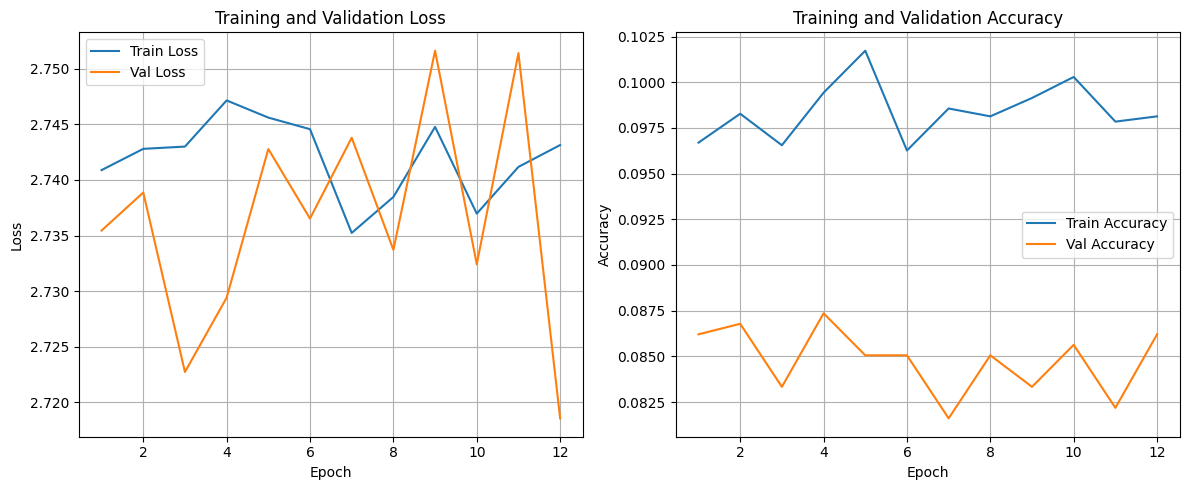

In [33]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

In [34]:
print(train_dataset.class_to_idx)

{'Bellis perennis': 0, 'Brassica napus': 1, 'Capsella bursa-pastoris': 2, 'Cichorium intybus': 3, 'Crepis capillaris': 4, 'Hieracium umbellatum': 5, 'Hypochaeris radicata': 6, 'Sonchus arvensis': 7, 'Tragopogon pratensis': 8, 'Tussilago farfara': 9}
